# Calories Burnt Prediction

A regression project that predicts the number of calories burned during a workout from biometric and exercise data (gender, age, height, weight, exercise duration, heart rate, body temperature).

**Pipeline:**
1. Problem definition
2. Dataset understanding & data quality
3. Feature engineering & exploratory data analysis
4. Data preparation
5. Feature selection (correlation, RFE)
6. Baseline models: hold-out evaluation + cross-validation
7. Hyperparameter tuning + repeated-split robustness check
8. Feature importance 
9. Final comparison

## Problem Definition and Domain Understanding

**Business context.** 
Fitness trackers and gym equipment often estimate calories burnt with generic heuristics that ignore individual physiology. A data-driven regression model that uses biometric signals recorded during a workout (heart rate, body temperature, duration) together with static attributes (age, weight, height, gender) can give a more personalized estimate.

**Task.** 
Predict Calories burnt during a workout session.

**Success criteria.** 
R2 and RMSE on a held-out test set are the primary metrics; MAE is reported as a directly interpretable average error in kcal. A model is useful if it clearly beats a trivial mean-prediction baseline (R2=0) and keeps MAE to a small fraction of the target's range (Calories spans 1-314 kcal).

**Data.** 
Two files, exercise.csv (session/biometric data) and calories.csv (target), joined on User_ID, 15,000 rows total.

Importing dependencies

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.base import clone
from sklearn.model_selection import (train_test_split, KFold, RandomizedSearchCV, GridSearchCV, cross_val_score, learning_curve)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

Data Import

In [7]:
exercise = pd.read_csv("exercise.csv")
calories = pd.read_csv("calories.csv")
#exercise.info()
#calories.info()
df = pd.merge(exercise, calories, on = "User_ID")
print(df.shape)

(15000, 9)


## Dataset Understanding

In [11]:
raw_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Descriptive statistics: numerical features\n")
display(df[raw_numeric_cols].describe(include='all'))

Descriptive statistics: numerical features



,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


**Findings:** 
Age spans 20-79 (mean 42.8), Duration up to 30 minutes, Heart_Rate 67-128 bpm and Body_Temp 37.1-41.5 (an elevated range for a resting body temperature, but expected since readings are taken during/after exercise).
Calories ranges from 1 to 314 kcal (mean 89.5) and is right-skewed, matching the skewness value computed later in Data Preparation.

In [12]:
print("Descriptive statistics: categorical features\n")
print(df["Gender"].value_counts())
print(f"\nGender share: \n{(df['Gender'].value_counts(normalize=True) * 100).round(1)}")

Descriptive statistics: categorical features

Gender
female    7553
male      7447
Name: count, dtype: int64

Gender share: 
Gender
female    50.4
male      49.6
Name: proportion, dtype: float64


**Findings:** Gender is almost perfectly balanced (50.4% female / 49.6% male, 7,553 vs 7,447 rows) with exactly two categories and no free-text inconsistencies.

## Data Quality

In [13]:
print("1. Missing values\n")
missing = df.isna().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values in any column.")
else:
    completeness = 1 - missing / len(df)
    display(pd.DataFrame({"missing_count": missing, "completeness": completeness.round(3)}))

1. Missing values

No missing values in any column.


In [14]:
print("2. Representation of expected values\n")
print(f"Gender categories: {sorted(df['Gender'].unique())}")
print(f"User_ID unique: {df['User_ID'].nunique()} / {len(df)} rows")

2. Representation of expected values

Gender categories: ['female', 'male']
User_ID unique: 15000 / 15000 rows


In [15]:
print("3. Plausibility checks\n")
checks = {
    "Age outside [10, 100]": ~df["Age"].between(10, 100),
    "Height outside [100, 250] cm": ~df["Height"].between(100, 250),
    "Weight outside [30, 200] kg": ~df["Weight"].between(30, 200),
    "Duration outside [0, 180] min": ~df["Duration"].between(0, 180),
    "Heart_Rate outside [30, 220] bpm": ~df["Heart_Rate"].between(30, 220),
    "Body_Temp outside [30, 45] C": ~df["Body_Temp"].between(30, 45),
    "Calories negative": df["Calories"] < 0,
}
for label, mask in checks.items():
    print(f"{label:35s}: {mask.sum()} rows")

3. Plausibility checks

Age outside [10, 100]              : 0 rows
Height outside [100, 250] cm       : 0 rows
Weight outside [30, 200] kg        : 0 rows
Duration outside [0, 180] min      : 0 rows
Heart_Rate outside [30, 220] bpm   : 0 rows
Body_Temp outside [30, 45] C       : 0 rows
Calories negative                  : 0 rows


In [16]:
print("4. Uniqueness\n")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate User_ID values: {df['User_ID'].duplicated().sum()}")

4. Uniqueness

Duplicate rows: 0
Duplicate User_ID values: 0


In [17]:
print("5. Zero values across numeric columns\n")
zero_found = False
for col in raw_numeric_cols:
    n_zero = (df[col] == 0).sum()
    if n_zero:
        zero_found = True
        print(f"{col}: {n_zero} zeros ({n_zero / len(df):.1%})")
if not zero_found:
    print("No zero values in any numeric column.")

5. Zero values across numeric columns

No zero values in any numeric column.


**Findings:** no missing values, no duplicate rows, all 15,000 User_ID values unique, no implausible or out-of-range readings, and no zero values in any numeric column. This is a clean dataset (the checks above act mainly as a safety net rather than uncovering real issues, and the same checks would be worth re-running if this pipeline were ever pointed at raw wearable-device exports instead).

## Feature Engineering

BMI (body mass index) and Workload (Duration * Heart_Rate, a proxy for total cardiovascular effort during the workout) are derived from the raw columns. Gender is label-encoded as Gender_Encoded for use in the numeric feature set.

In [19]:
df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)
df["Gender_Encoded"] = df["Gender"].map({"male": 1, "female": 0})
df["Workload"] = df["Duration"] * df["Heart_Rate"]

num_columns = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp", "Calories", "BMI", "Gender_Encoded", "Workload"]

In [21]:
df.info()

target_corr = df[num_columns].corr()["Calories"].drop("Calories")
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
print("\nCorrelation with target (Calories), sorted by corr:")
print(target_corr)

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User_ID         15000 non-null  int64  
 1   Gender          15000 non-null  str    
 2   Age             15000 non-null  int64  
 3   Height          15000 non-null  float64
 4   Weight          15000 non-null  float64
 5   Duration        15000 non-null  float64
 6   Heart_Rate      15000 non-null  float64
 7   Body_Temp       15000 non-null  float64
 8   Calories        15000 non-null  float64
 9   BMI             15000 non-null  float64
 10  Gender_Encoded  15000 non-null  int64  
 11  Workload        15000 non-null  float64
dtypes: float64(8), int64(3), str(1)
memory usage: 1.4 MB

Correlation with target (Calories), sorted by corr:
Workload          0.974597
Duration          0.955421
Heart_Rate        0.897882
Body_Temp         0.824558
Age               0.154395
BMI               0.056473

**Findings:** the engineered Workload feature has the strongest correlation with Calories, even stronger than Duration or Heart_Rate alone, confirming it captures useful signal beyond either input individually. Body_Temp is also strongly correlated. Static attributes Age, BMI, Weight, Height, Gender_Encoded correlate weakly with the target <= 0.15, so this target is driven almost entirely by exercise-intensity signals rather than who the person is.

## Exploratory Data Analysis

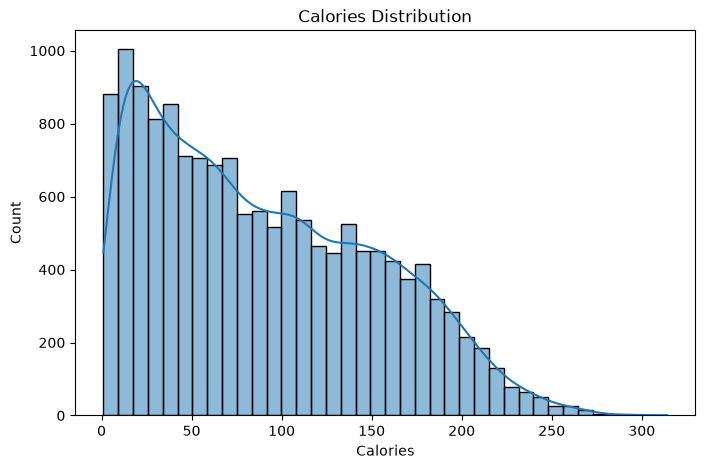

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Calories"], kde=True).set_title("Calories Distribution")
plt.show()

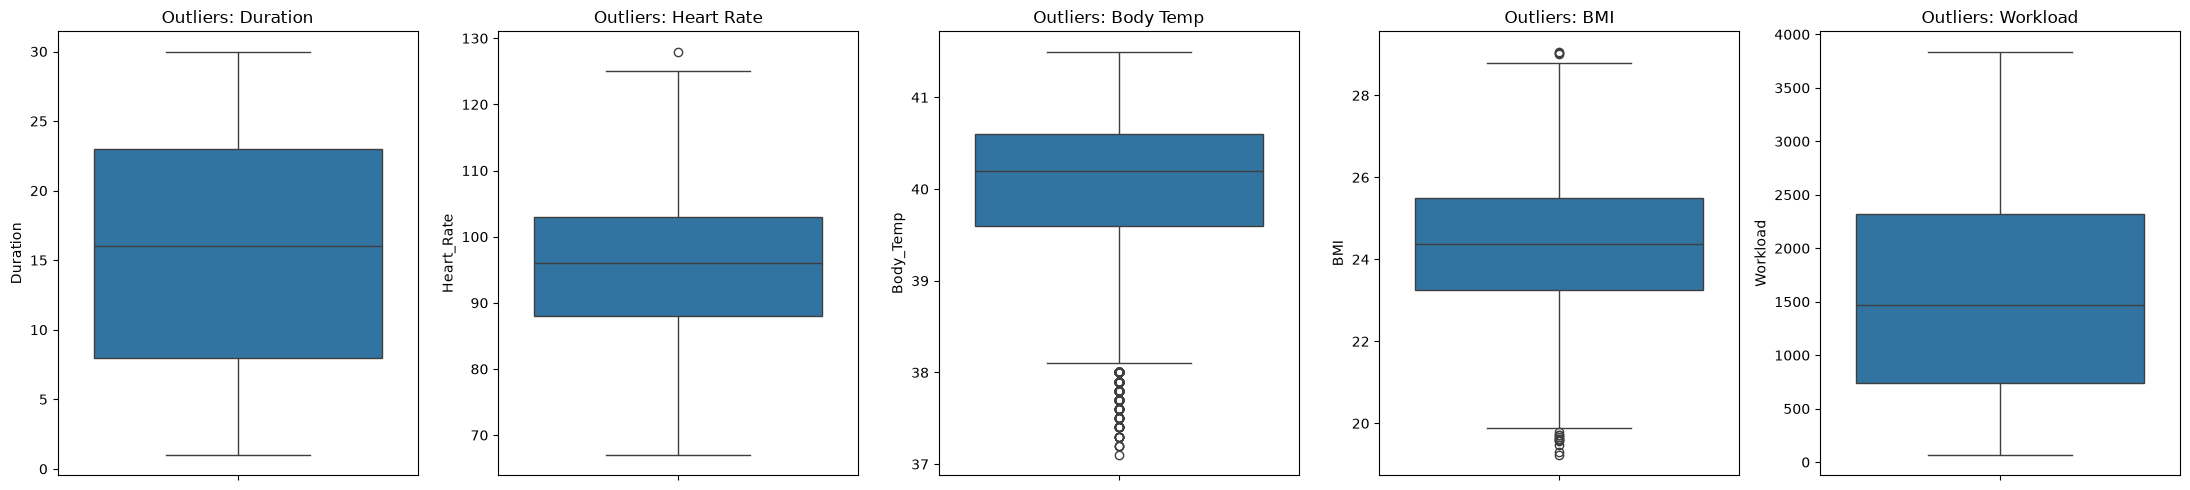

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
sns.boxplot(y=df["Duration"], ax=axes[0]).set_title("Outliers: Duration")
sns.boxplot(y=df["Heart_Rate"], ax=axes[1]).set_title("Outliers: Heart Rate")
sns.boxplot(y=df["Body_Temp"], ax=axes[2]).set_title("Outliers: Body Temp")
sns.boxplot(y=df["BMI"], ax=axes[3]).set_title("Outliers: BMI")
sns.boxplot(y=df["Workload"], ax=axes[4]).set_title("Outliers: Workload")
plt.tight_layout()
plt.show()

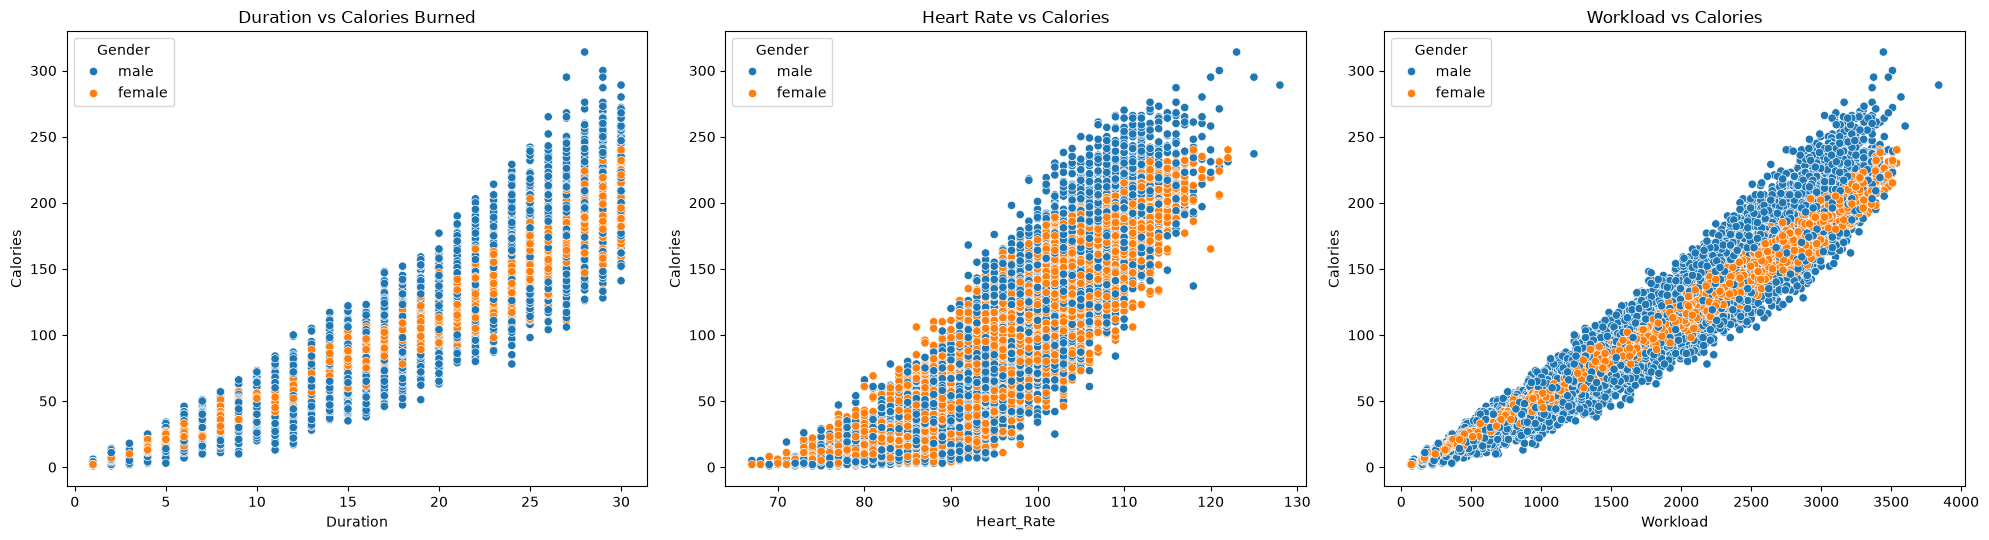

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
sns.scatterplot(data=df, x="Duration", y="Calories", hue="Gender", ax=axes[0])
axes[0].set_title("Duration vs Calories Burned")
sns.scatterplot(data=df, x="Heart_Rate", y="Calories", hue="Gender", ax=axes[1])
axes[1].set_title("Heart Rate vs Calories")
sns.scatterplot(data=df, x="Workload", y="Calories", hue="Gender", ax=axes[2])
axes[2].set_title("Workload vs Calories")
plt.tight_layout()
plt.show()

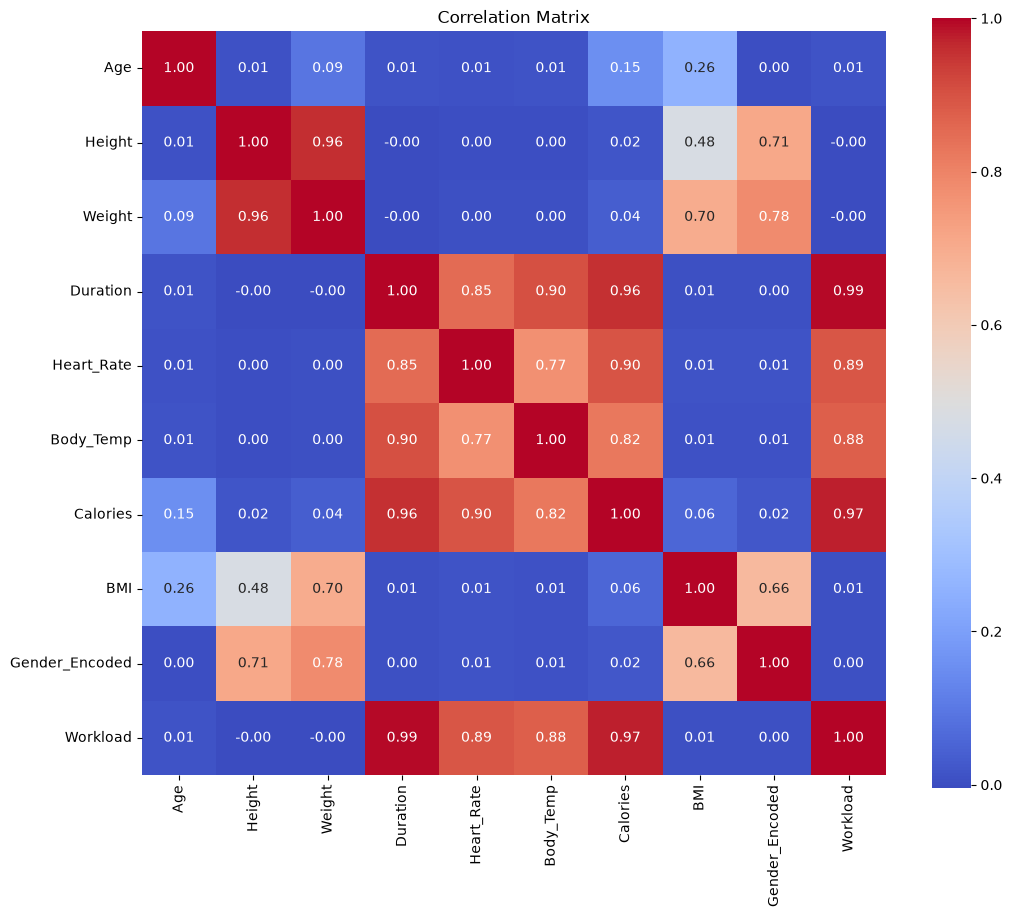

In [25]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

**Findings:** the Calories distribution is right-skewed with a long tail toward high values. Heart_Rate, Body_Temp, BMI and Workload each show a handful of upper-tail boxplot outliers, which is why they are the columns clipped in the next section. The scatterplots confirm a strong, roughly linear relationship between Duration/Heart_Rate/Workload and Calories, and the correlation heatmap reproduces the same ranking already seen in the profiling summary above.

## Data Preparation

In [26]:
calories_skew = df["Calories"].skew()
duration_skew = df["Duration"].skew()

print(f"Calories Skewness: {calories_skew:.2f}")
print(f"Duration Skewness: {duration_skew:.2f}")

Calories Skewness: 0.51
Duration Skewness: 0.00


### Train/Test Split

The split is performed before any outlier clipping, feature selection or scaling so that no information from the test set leaks into decisions made on the training set.

In [28]:
X = df.drop(columns=["Calories", "User_ID", "Gender"])
y = df["Calories"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_test = X_train.copy(), X_test.copy()

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train: (12000, 9)
X_test : (3000, 9)


### Outlier Clipping

IQR bounds are computed only from the training set and then applied to both the training and test sets, so the test set never influences how outliers are defined.

In [29]:
def compute_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

def clip_with_bounds(dataframe, column, lower, upper):
    dataframe[column] = dataframe[column].clip(lower, upper)
    return dataframe

columns_with_outliers = ["Heart_Rate", "Body_Temp", "BMI", "Workload"]

for col in columns_with_outliers:
    lower, upper = compute_iqr_bounds(X_train[col])
    X_train = clip_with_bounds(X_train, col, lower, upper)
    X_test = clip_with_bounds(X_test, col, lower, upper)
    print(f"{col}: bounds fitted on train = [{lower:.2f}, {upper:.2f}]")

Heart_Rate: bounds fitted on train = [65.50, 125.50]
Body_Temp: bounds fitted on train = [38.10, 42.10]
BMI: bounds fitted on train = [19.84, 28.88]
Workload: bounds fitted on train = [-1625.00, 4671.00]


In [30]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"Missing values remaining train: {np.isnan(X_train_processed).sum()}")
print(f"Missing values remaining test: {np.isnan(X_test_processed).sum()}")

X_train_processed shape: (12000, 9)
X_test_processed shape: (3000, 9)
Missing values remaining train: 0
Missing values remaining test: 0


## Feature Selection

With only 9 candidate features, aggressive dimensionality reduction (e.g. PCA) is not needed. Instead, correlation and Recursive Feature Elimination (RFE) are used to understand which features matter most and to sanity-check that the engineered features pull their weight.

In [32]:
train_corr_df = X_train.copy()
train_corr_df["Calories"] = y_train
feature_target_corr = train_corr_df.corr()["Calories"].drop("Calories")
feature_target_corr = feature_target_corr.reindex(feature_target_corr.abs().sort_values(ascending=False).index)

print("Pearson correlation with target\n")
print(feature_target_corr)

Pearson correlation with target

Workload          0.974453
Duration          0.955173
Heart_Rate        0.897393
Body_Temp         0.834198
Age               0.153091
BMI               0.060150
Weight            0.035417
Gender_Encoded    0.021508
Height            0.015936
Name: Calories, dtype: float64


**Findings:** the train-only correlations (Workload 0.974, Duration 0.955, Heart_Rate 0.897, Body_Temp 0.834, Age 0.153, BMI 0.060, Weight 0.035, Gender_Encoded 0.022, Height 0.016 closely match the full-dataset correlations computed earlier, confirming the train/test split did not introduce any meaningful shift in the feature-target relationships.

 n_features  mean_r2
          2 0.961926
          3 0.963261
          4 0.965532
          5 0.966805
          6 0.984421
          7 0.984421
          8 0.984420
          9 0.984417


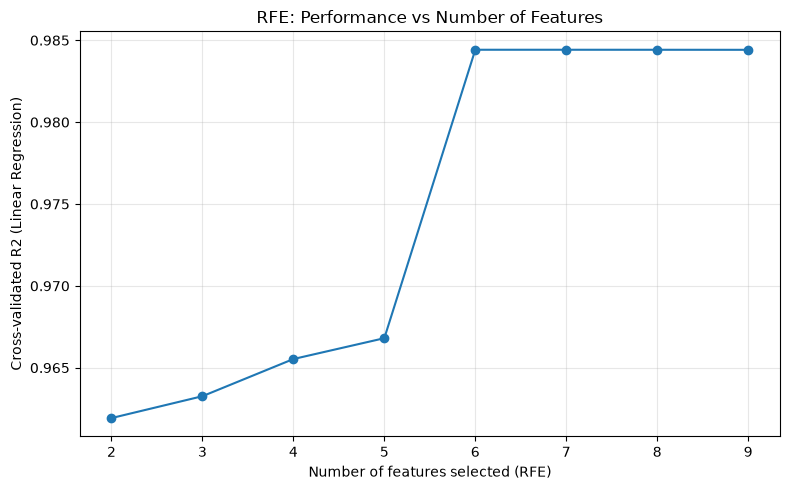

In [34]:
n_features_range = list(range(2, len(numeric_features) + 1))
rfe_results = []
for n in n_features_range:
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n)
    rfe.fit(X_train_processed, y_train)
    selected = [f for f, s in zip(numeric_features, rfe.support_) if s]
    scores = cross_val_score(
        LinearRegression(), X_train_processed[:, rfe.support_], y_train, cv=cv, scoring="r2"
    )
    rfe_results.append({"n_features": n, "mean_r2": scores.mean(), "features": selected})

rfe_df = pd.DataFrame(rfe_results)
print(rfe_df[["n_features", "mean_r2"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rfe_df["n_features"], rfe_df["mean_r2"], marker="o")
ax.set_xlabel("Number of features selected (RFE)")
ax.set_ylabel("Cross-validated R2 (Linear Regression)")
ax.set_title("RFE: Performance vs Number of Features")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Findings and decision:** cross-validated R2 jumps from 0.967 (5 features) to 0.984 (6 features) and then stays essentially flat through all 9 features. None of the remaining features are redundant enough to justify dropping them, and since the full feature set is only 9 columns to begin with, all 9 are kept for every downstream model (RFE here is a diagnostic confirming there is little to gain from feature elimination, not a filtering step). Tree ensembles handle any mild redundancy (e.g. Workload vs. Duration/Heart_Rate) natively.

## Baseline Model Training and Evaluation

In [36]:
baseline_models = {
    "DecisionTree": DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=15),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

fitted_models = {}
results = []

for name, model in baseline_models.items():
    model.fit(X_train_processed, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test_processed)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    print(f"{name}")
    print(f"R2 Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}\n")

metrics_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(metrics_df.to_string(index=False))

DecisionTree
R2 Score : 0.9818
RMSE     : 8.5780
MAE      : 6.0636

KNN
R2 Score : 0.9946
RMSE     : 4.6487
MAE      : 3.3300

LinearRegression
R2 Score : 0.9845
RMSE     : 7.9001
MAE      : 5.8278

Ridge
R2 Score : 0.9845
RMSE     : 7.9057
MAE      : 5.8126

RandomForest
R2 Score : 0.9953
RMSE     : 4.3641
MAE      : 3.0426

GradientBoosting
R2 Score : 0.9979
RMSE     : 2.9063
MAE      : 2.1284

           Model  R2 Score     RMSE      MAE
GradientBoosting  0.997907 2.906273 2.128411
    RandomForest  0.995281 4.364081 3.042627
             KNN  0.994645 4.648703 3.330000
LinearRegression  0.984536 7.900059 5.827844
           Ridge  0.984513 7.905732 5.812625
    DecisionTree  0.981767 8.578036 6.063597


### Cross-validation

A single train/test split can be noisy. 5-fold cross-validation on the training set gives a more robust estimate of how each baseline model generalizes.

In [37]:
cv_results = []
for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring="r2", n_jobs=-1)
    cv_results.append({"Model": name, "CV R2 Mean": scores.mean(), "CV R2 Std": scores.std()})
    print(f"{name}: CV R2 = {scores.mean():.4f} +/- {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values(by="CV R2 Mean", ascending=False)
print("\n" + cv_df.to_string(index=False))

DecisionTree: CV R2 = 0.9807 +/- 0.0004
KNN: CV R2 = 0.9936 +/- 0.0003
LinearRegression: CV R2 = 0.9844 +/- 0.0003
Ridge: CV R2 = 0.9844 +/- 0.0003
RandomForest: CV R2 = 0.9948 +/- 0.0001
GradientBoosting: CV R2 = 0.9974 +/- 0.0001

           Model  CV R2 Mean  CV R2 Std
GradientBoosting    0.997363   0.000109
    RandomForest    0.994810   0.000138
             KNN    0.993607   0.000316
LinearRegression    0.984417   0.000321
           Ridge    0.984397   0.000341
    DecisionTree    0.980705   0.000385


### Polynomial feature expansion

Linear Regression can only fit a hyperplane. Expanding the features with degree-2 polynomial terms lets it capture simple interactions and curvature, at the cost of more parameters and a higher risk of overfitting.

In [38]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

poly_lin_reg = LinearRegression()
poly_lin_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_lin_reg.predict(X_test_poly)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)

lin_pred = fitted_models["LinearRegression"].predict(X_test_processed)
print(f"Polynomial (degree=2) LinearRegression: R2={r2_poly:.4f}  RMSE={rmse_poly:.4f}  MAE={mae_poly:.4f}")
print(f"Plain LinearRegression baseline       : "
      f"R2={r2_score(y_test, lin_pred):.4f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_test, lin_pred)):.4f}  "
      f"MAE={mean_absolute_error(y_test, lin_pred):.4f}")

Polynomial (degree=2) LinearRegression: R2=0.9987  RMSE=2.3281  MAE=1.7150
Plain LinearRegression baseline       : R2=0.9845  RMSE=7.9001  MAE=5.8278


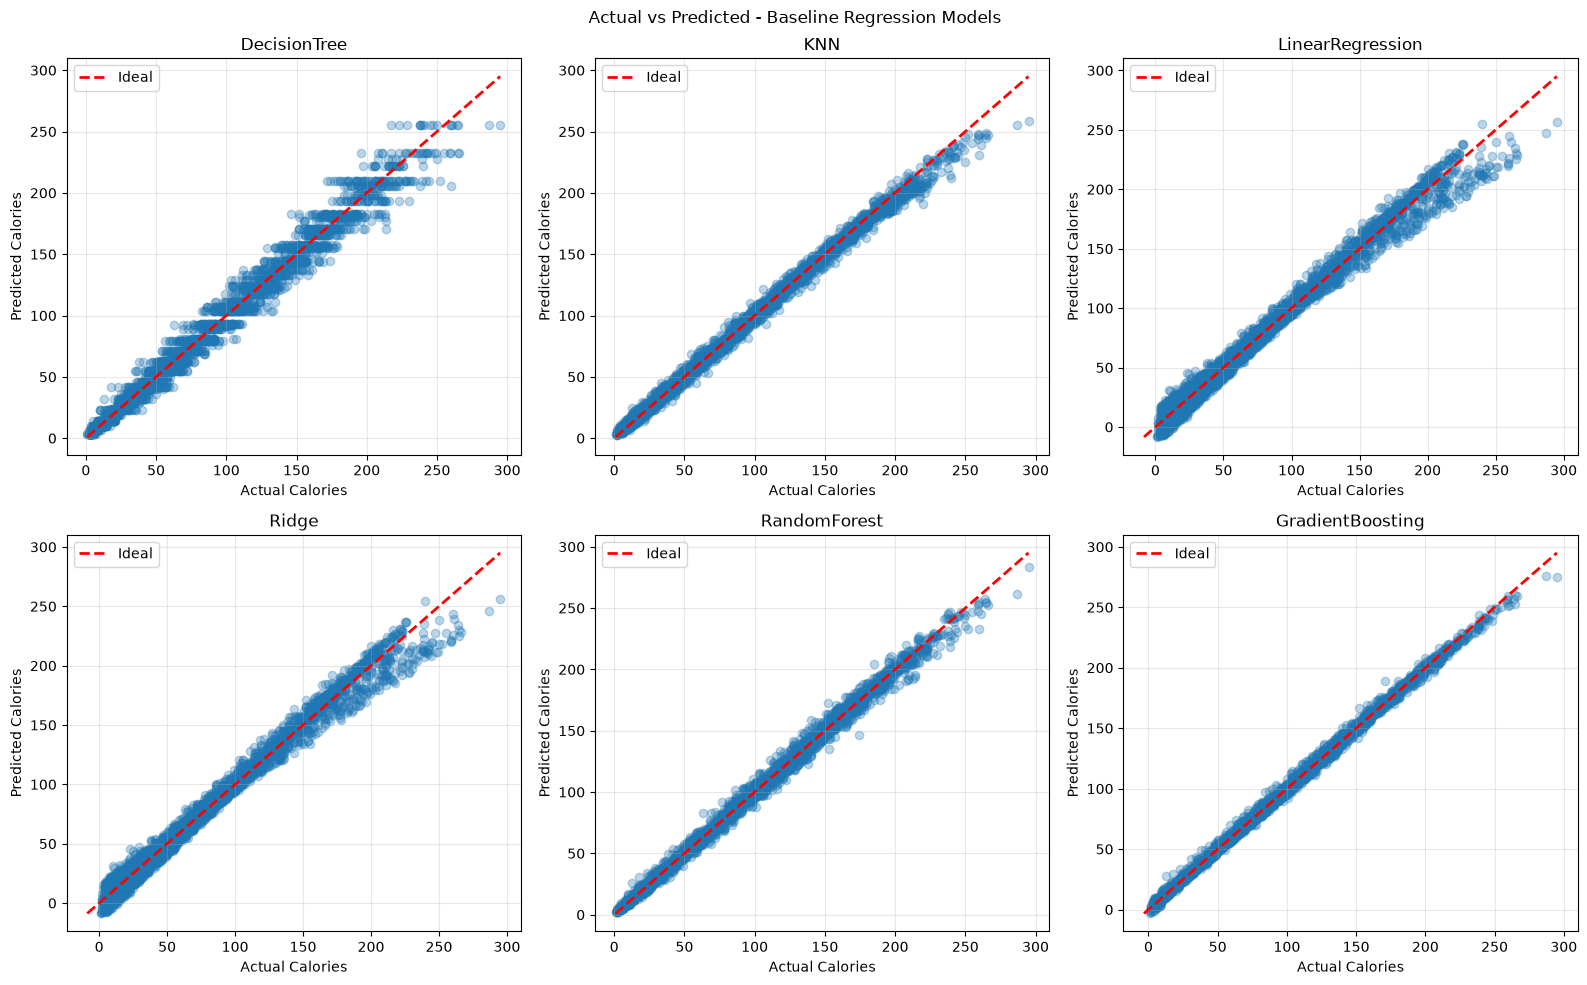

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_processed)

    ax.scatter(y_test, y_pred, alpha=0.3)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Ideal")

    ax.set_title(f"{name}")
    ax.set_xlabel("Actual Calories")
    ax.set_ylabel("Predicted Calories")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

for ax in axes[len(fitted_models):]:
    ax.axis("off")

plt.suptitle("Actual vs Predicted - Baseline Regression Models")
plt.tight_layout()
plt.show()

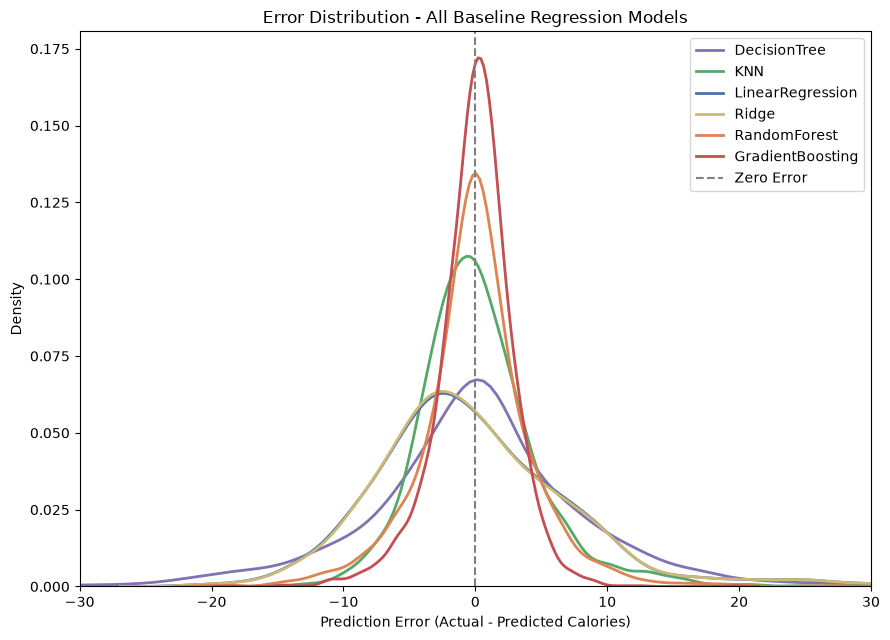

In [41]:
plt.figure(figsize=(9, 6.5))

model_colors = {
    "DecisionTree": "#8172B2",
    "KNN": "#55A868",
    "LinearRegression": "#4C72B0",
    "Ridge": "#CCB974",
    "RandomForest": "#DD8452",
    "GradientBoosting": "#C44E52",
}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_processed)
    residuals = y_test - y_pred

    sns.kdeplot(residuals, color=model_colors.get(name, "black"), label=f"{name}", linewidth=2)

plt.axvline(0, color="gray", linestyle="--", label="Zero Error")
plt.xlabel("Prediction Error (Actual - Predicted Calories)")
plt.ylabel("Density")
plt.title("Error Distribution - All Baseline Regression Models")
plt.xlim(-30, 30)
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [43]:
rf_param_grid = {
    "n_estimators": [150, 250],
    "max_depth": [6, 8, 10],
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=5,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train_processed, y_train)

gb_param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
}
gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=gb_param_grid,
    n_iter=5,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_search.fit(X_train_processed, y_train)

knn_param_grid = {
    "n_neighbors": [5, 10, 15, 20, 25],
    "weights": ["uniform", "distance"],
}
knn_search = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
)
knn_search.fit(X_train_processed, y_train)

lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

tuned_models = {
    "LinearRegression": lin_reg,
    "KNN_tuned": knn_search.best_estimator_,
    "RandomForest_tuned": rf_search.best_estimator_,
    "GradientBoosting_tuned": gb_search.best_estimator_,
}

print("Best Random Forest params:", rf_search.best_params_)
print("Best GradientBoosting params:", gb_search.best_params_)
print("Best KNN params:", knn_search.best_params_)

Best Random Forest params: {'n_estimators': 250, 'max_depth': 10}
Best GradientBoosting params: {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.1}
Best KNN params: {'n_neighbors': 15, 'weights': 'distance'}


Test-set evaluation: tuned models

LinearRegression
R2 Score : 0.9845
RMSE     : 7.9001
MAE      : 5.8278

KNN_tuned
R2 Score : 0.9950
RMSE     : 4.4855
MAE      : 3.2228

RandomForest_tuned
R2 Score : 0.9974
RMSE     : 3.2091
MAE      : 2.1714

GradientBoosting_tuned
R2 Score : 0.9995
RMSE     : 1.3942
MAE      : 0.9628

Baseline vs Tuned: Test R2 Score Comparison
LinearRegression  : baseline=0.9845  tuned=0.9845
KNN               : baseline=0.9946  tuned=0.9950
RandomForest      : baseline=0.9953  tuned=0.9974
GradientBoosting  : baseline=0.9979  tuned=0.9995


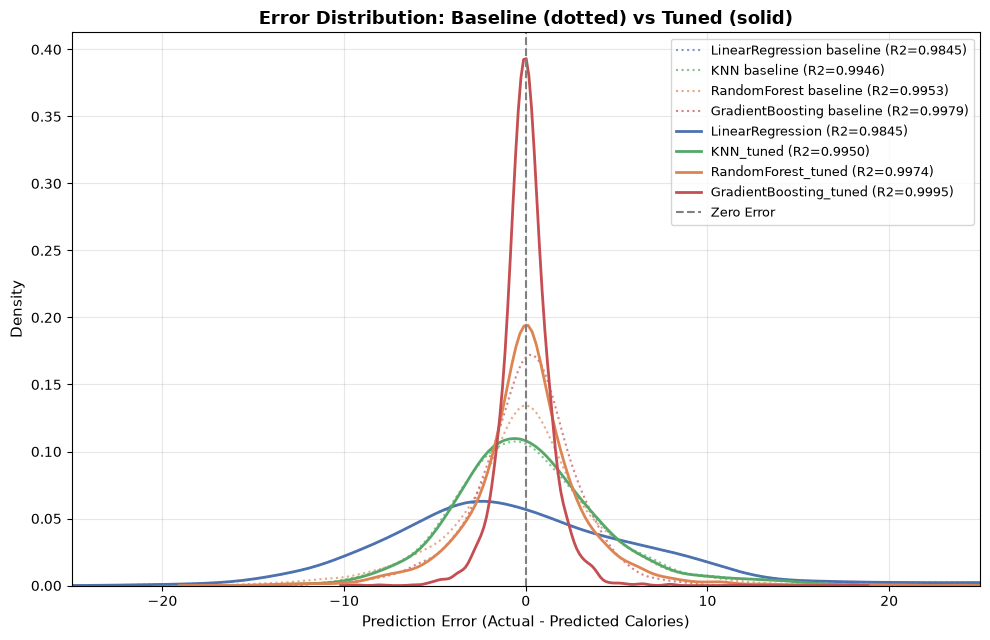

In [45]:
baseline_test_metrics = {}
for name, model in fitted_models.items():
    y_pred = model.predict(X_test_processed)
    baseline_test_metrics[name] = {
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    }

print("Test-set evaluation: tuned models\n")
tuned_test_metrics = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_processed)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    tuned_test_metrics[name] = {"R2": r2, "RMSE": rmse, "MAE": mae}

    print(f"{name}")
    print(f"R2 Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}\n")

print("Baseline vs Tuned: Test R2 Score Comparison")
for base_name in ["LinearRegression", "KNN", "RandomForest", "GradientBoosting"]:
    tuned_key = base_name if base_name == "LinearRegression" else f"{base_name}_tuned"
    print(f"{base_name:<18}: baseline={baseline_test_metrics[base_name]['R2']:.4f}  "
          f"tuned={tuned_test_metrics[tuned_key]['R2']:.4f}")

plt.figure(figsize=(10, 6.5))

model_colors = {
    "LinearRegression": "#4C72B0",
    "KNN": "#55A868",
    "RandomForest": "#DD8452",
    "GradientBoosting": "#C44E52",
}

for base_name in model_colors:
    base_model = fitted_models[base_name]
    y_pred_base = base_model.predict(X_test_processed)
    residuals_base = y_test - y_pred_base
    r2_base = baseline_test_metrics[base_name]["R2"]

    sns.kdeplot(residuals_base, color=model_colors[base_name], linestyle=":", linewidth=1.5, alpha=0.7,
                label=f"{base_name} baseline (R2={r2_base:.4f})")

for tuned_name, tuned_model in tuned_models.items():
    base_name = tuned_name.replace("_tuned", "")
    y_pred_tuned = tuned_model.predict(X_test_processed)
    residuals_tuned = y_test - y_pred_tuned
    r2_tuned = tuned_test_metrics[tuned_name]["R2"]

    sns.kdeplot(residuals_tuned, color=model_colors[base_name], linestyle="-", linewidth=2,
                label=f"{tuned_name} (R2={r2_tuned:.4f})")

plt.axvline(0, color="gray", linestyle="--", label="Zero Error")
plt.xlabel("Prediction Error (Actual - Predicted Calories)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title("Error Distribution: Baseline (dotted) vs Tuned (solid)", fontsize=13, fontweight="bold")
plt.xlim(-25, 25)
plt.legend(fontsize=9, loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Repeated-Split Robustness Check

Hyperparameter tuning above used a single 80/20 split. To check whether the tuned models' apparent edge over the baselines is real or just noise from that particular split, each tuned/baseline pair is refit and re-evaluated across N independent random splits, and the mean R2 difference is reported with its 95% confidence interval.

In [46]:
N_REPEATS = 10

baseline_configs = {
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=15),
}
tuned_configs = {
    "RandomForest": rf_search.best_estimator_,
    "GradientBoosting": gb_search.best_estimator_,
    "KNN": knn_search.best_estimator_,
}

repeated_records = []
for seed in range(N_REPEATS):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    X_tr, X_te = X_tr.copy(), X_te.copy()

    for col in columns_with_outliers:
        lo, hi = compute_iqr_bounds(X_tr[col])
        X_tr = clip_with_bounds(X_tr, col, lo, hi)
        X_te = clip_with_bounds(X_te, col, lo, hi)

    split_preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ])
    X_tr_proc = split_preprocessor.fit_transform(X_tr)
    X_te_proc = split_preprocessor.transform(X_te)

    for name in baseline_configs:
        base_model = clone(baseline_configs[name])
        base_model.fit(X_tr_proc, y_tr)
        base_r2 = r2_score(y_te, base_model.predict(X_te_proc))

        tuned_model = clone(tuned_configs[name])
        tuned_model.fit(X_tr_proc, y_tr)
        tuned_r2 = r2_score(y_te, tuned_model.predict(X_te_proc))

        repeated_records.append({
            "Model": name, "Split_seed": seed,
            "Baseline_R2": base_r2, "Tuned_R2": tuned_r2, "Diff": tuned_r2 - base_r2,
        })

repeated_df = pd.DataFrame(repeated_records)

summary_rows = []
for name, sub in repeated_df.groupby("Model"):
    diffs = sub["Diff"].values
    mean_diff = diffs.mean()
    se = diffs.std(ddof=1) / np.sqrt(len(diffs))
    ci_low, ci_high = mean_diff - 1.96 * se, mean_diff + 1.96 * se
    summary_rows.append({
        "Model": name,
        "Mean baseline R2": sub["Baseline_R2"].mean(),
        "Mean tuned R2": sub["Tuned_R2"].mean(),
        "Mean diff (tuned-baseline)": mean_diff,
        "95% CI low": ci_low, "95% CI high": ci_high,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(f"Repeated random splits: {N_REPEATS} (seeds 0-{N_REPEATS - 1})\n")
print(summary_df.round(4).to_string())

Repeated random splits: 10 (seeds 0-9)

                  Mean baseline R2  Mean tuned R2  Mean diff (tuned-baseline)  95% CI low  95% CI high
Model                                                                                                 
GradientBoosting            0.9974         0.9995                      0.0021      0.0020       0.0022
KNN                         0.9942         0.9946                      0.0004      0.0004       0.0004
RandomForest                0.9949         0.9972                      0.0023      0.0022       0.0024


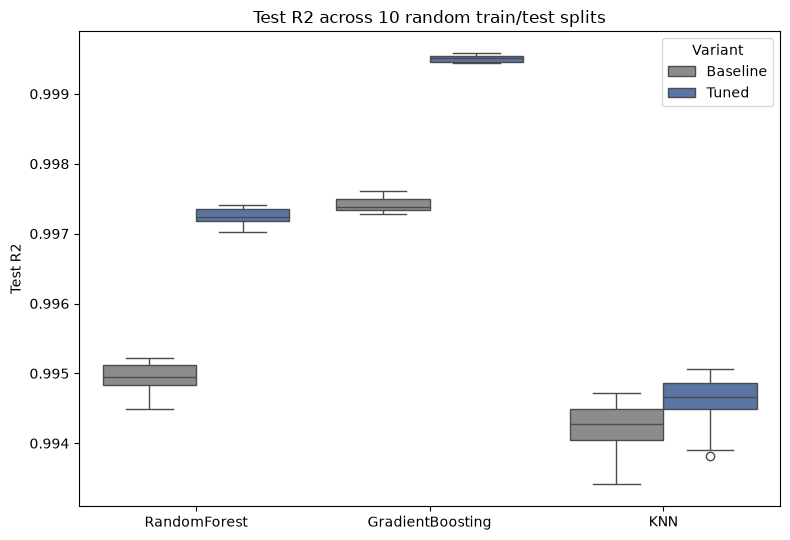

In [47]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_df = repeated_df.melt(id_vars=["Model", "Split_seed"], value_vars=["Baseline_R2", "Tuned_R2"],
                            var_name="Variant", value_name="Test_R2")
plot_df["Variant"] = plot_df["Variant"].str.replace("_R2", "", regex=False)

sns.boxplot(data=plot_df, x="Model", y="Test_R2", hue="Variant",
            palette={"Baseline": "#8C8C8C", "Tuned": "#4C72B0"}, ax=ax)
ax.set_title(f"Test R2 across {N_REPEATS} random train/test splits")
ax.set_ylabel("Test R2")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Findings:** across 10 independent random splits, tuning shows a small but consistent improvement over the matching baseline for every model, and all three 95% confidence intervals exclude zero: RandomForest +0.0023 R2 , GradientBoosting +0.0021 R2 , KNN +0.0004 R2 . The tuning gains for RandomForest and GradientBoosting are real and reproducible, not an artifact of the single 80/20 split used for the search itself; KNN's tuned edge is real too, just much smaller in absolute terms.

## Feature Importance

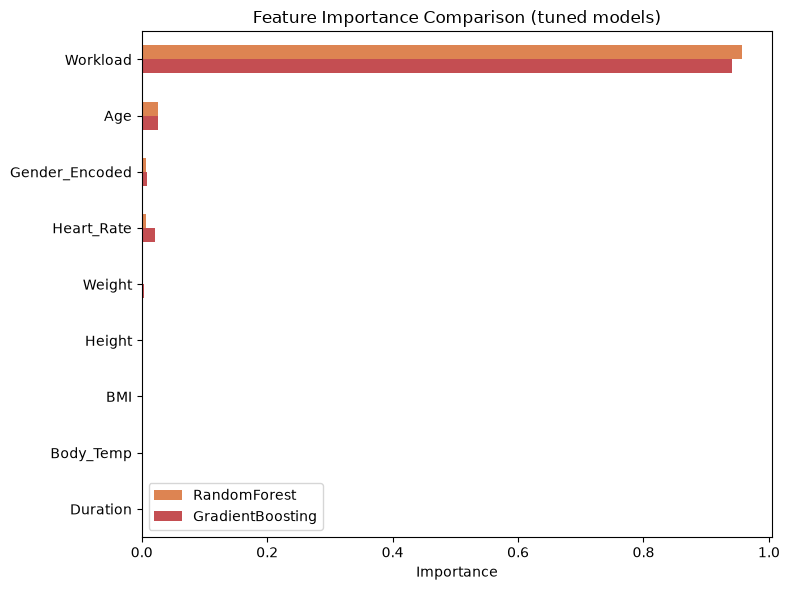

                RandomForest  GradientBoosting
Workload            0.957778          0.941437
Age                 0.025430          0.025948
Gender_Encoded      0.007521          0.008254
Heart_Rate          0.006483          0.020930
Weight              0.001681          0.003220
Height              0.000604          0.000049
BMI                 0.000342          0.000039
Body_Temp           0.000099          0.000021
Duration            0.000062          0.000102


In [48]:
importance_df = pd.DataFrame({
    "RandomForest": tuned_models["RandomForest_tuned"].feature_importances_,
    "GradientBoosting": tuned_models["GradientBoosting_tuned"].feature_importances_,
}, index=numeric_features).sort_values(by="RandomForest", ascending=False)

importance_df.plot(kind="barh", figsize=(8, 6), color=["#DD8452", "#C44E52"])
plt.title("Feature Importance Comparison (tuned models)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df)

### SHAP Values

SHAP values give a per-feature, per-prediction contribution, which is more reliable than impurity-based importance when features are correlated. Exact tree SHAP is expensive, so it is computed on a random sample of the test set rather than all 3,000 rows.

In [49]:
X_test_df = pd.DataFrame(X_test_processed, columns=numeric_features)
X_shap_sample = X_test_df.sample(n=200, random_state=RANDOM_STATE)

explainer_rf = shap.TreeExplainer(tuned_models["RandomForest_tuned"])
shap_values_rf = explainer_rf(X_shap_sample)

explainer_gb = shap.TreeExplainer(tuned_models["GradientBoosting_tuned"])
shap_values_gb = explainer_gb(X_shap_sample)

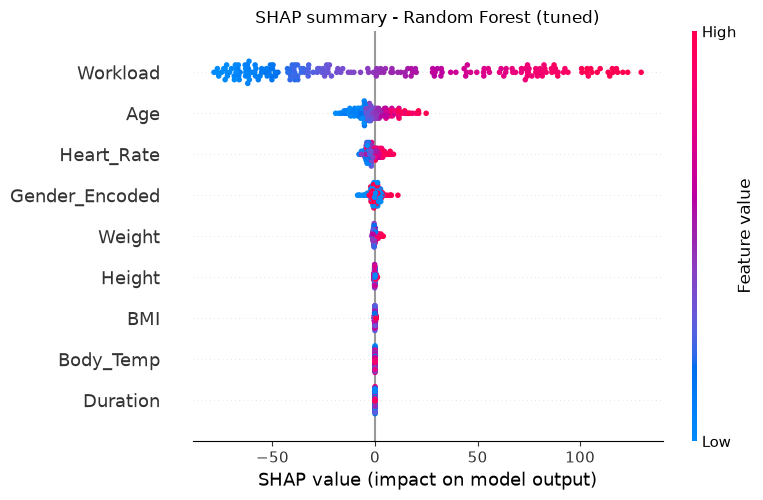

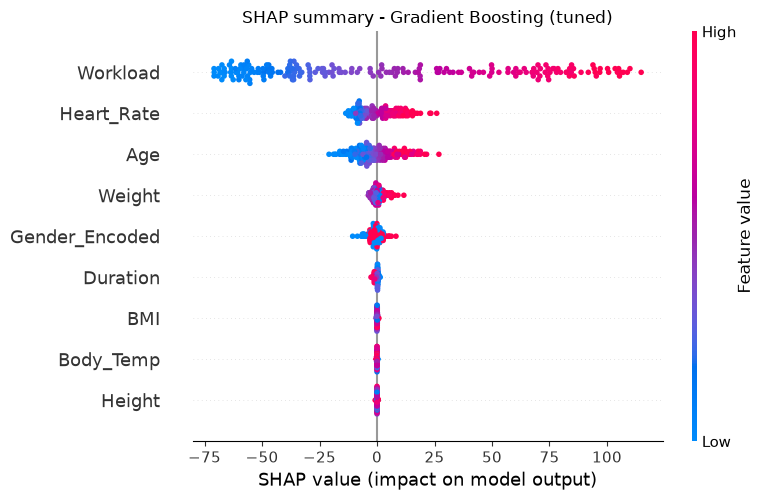

In [50]:
shap.summary_plot(shap_values_rf, X_shap_sample, max_display=15, show=False)
plt.title("SHAP summary - Random Forest (tuned)")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_gb, X_shap_sample, max_display=15, show=False)
plt.title("SHAP summary - Gradient Boosting (tuned)")
plt.tight_layout()
plt.show()

In [51]:
def shap_rank_table(shap_values, impurity_importances, feature_names, top_n=15):
    mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_names)
    shap_rank = mean_abs_shap.rank(ascending=False)
    impurity_rank = impurity_importances.reindex(feature_names).rank(ascending=False)
    table = pd.DataFrame({
        "Mean SHAP": mean_abs_shap,
        "SHAP rank": shap_rank,
        "Impurity rank": impurity_rank,
        "Rank shift (impurity - SHAP)": impurity_rank - shap_rank,
    }).sort_values("Mean SHAP", ascending=False)
    return table.head(top_n)

print("Random Forest - SHAP rank vs impurity rank:")
print(shap_rank_table(shap_values_rf, importance_df["RandomForest"], numeric_features).round(3).to_string())
print()
print("Gradient Boosting - SHAP rank vs impurity rank:")
print(shap_rank_table(shap_values_gb, importance_df["GradientBoosting"], numeric_features).round(3).to_string())

Random Forest - SHAP rank vs impurity rank:
                Mean SHAP  SHAP rank  Impurity rank  Rank shift (impurity - SHAP)
Workload           54.197        1.0            1.0                           0.0
Age                 6.980        2.0            2.0                           0.0
Heart_Rate          2.921        3.0            4.0                           1.0
Gender_Encoded      1.773        4.0            3.0                          -1.0
Weight              0.691        5.0            5.0                           0.0
Height              0.228        6.0            6.0                           0.0
BMI                 0.124        7.0            7.0                           0.0
Body_Temp           0.018        8.0            8.0                           0.0
Duration            0.017        9.0            9.0                           0.0

Gradient Boosting - SHAP rank vs impurity rank:
                Mean SHAP  SHAP rank  Impurity rank  Rank shift (impurity - SHAP)
Workl

**Findings:** SHAP mostly agrees with impurity-based importance for both tuned models. Workload dominates by a wide margin (mean SHAP approx. 54 for RandomForest, approx. 50 for GradientBoosting), with Age and Heart_Rate a distant second and third. The largest disagreement is Height in GradientBoosting; every other feature shifts by at most one rank. This suggests the impurity-based rankings used in the previous section are not being meaningfully distorted by collinearity between Workload, Duration and Heart_Rate.

## Learning Curve

Best tuned model on the test set: GradientBoosting_tuned (R2=0.9995)


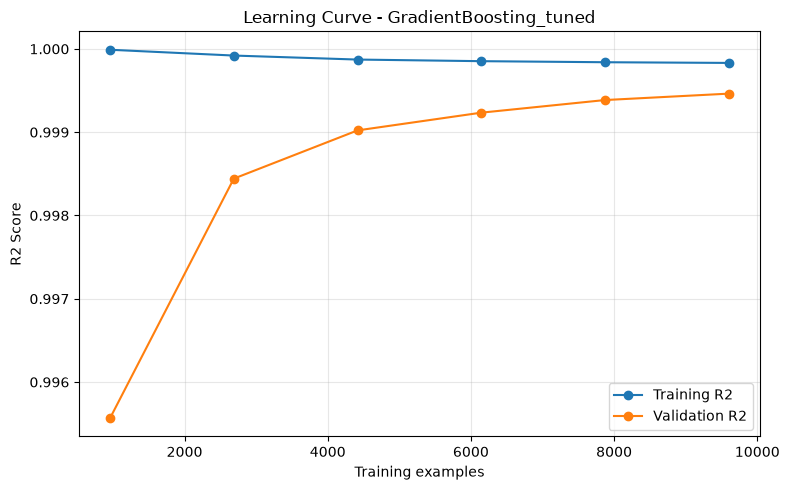

In [52]:
best_name = max(tuned_test_metrics, key=lambda k: tuned_test_metrics[k]["R2"])
best_model = tuned_models[best_name]
print(f"Best tuned model on the test set: {best_name} (R2={tuned_test_metrics[best_name]['R2']:.4f})")

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_processed, y_train,
    cv=cv, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training R2")
plt.plot(train_sizes, val_mean, marker="o", label="Validation R2")
plt.xlabel("Training examples")
plt.ylabel("R2 Score")
plt.title(f"Learning Curve - {best_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ensemble: Voting Regressor

In [53]:
voting_reg = VotingRegressor(estimators=[
    ("rf", tuned_models["RandomForest_tuned"]),
    ("gb", tuned_models["GradientBoosting_tuned"]),
    ("knn", tuned_models["KNN_tuned"]),
])
voting_reg.fit(X_train_processed, y_train)
y_pred_voting = voting_reg.predict(X_test_processed)

r2_voting = r2_score(y_test, y_pred_voting)
rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))
mae_voting = mean_absolute_error(y_test, y_pred_voting)

tuned_models["VotingEnsemble"] = voting_reg
tuned_test_metrics["VotingEnsemble"] = {"R2": r2_voting, "RMSE": rmse_voting, "MAE": mae_voting}

## Final Model Comparison

In [55]:
final_summary = pd.DataFrame(tuned_test_metrics).T.sort_values(by="R2", ascending=False)
print(final_summary)

best_final_name = final_summary.index[0]
best_final_model = tuned_models[best_final_name]
print(f"\nBest model: {best_final_name} (R2={final_summary.loc[best_final_name, 'R2']:.4f})")

                              R2      RMSE       MAE
GradientBoosting_tuned  0.999518  1.394179  0.962847
VotingEnsemble          0.998803  2.197931  1.507572
RandomForest_tuned      0.997448  3.209120  2.171419
KNN_tuned               0.995015  4.485493  3.222758
LinearRegression        0.984536  7.900059  5.827844

Best model: GradientBoosting_tuned (R2=0.9995)


## Conclusions and Recommendations

- **Best single-split baseline:** GradientBoosting (R2=0.9979, RMSE=2.91 kcal, MAE=2.13 kcal), ahead of RandomForest (R2=0.9953) and KNN (R2=0.9946); LinearRegression and Ridge are close to each other (R2 approx. 0.9845) and clearly behind the non-linear models.
- **Best by 5-fold cross-validation:** the same ranking holds GradientBoosting is the most accurate and also the most stable baseline model.
- **Hyperparameter tuning** improved every tuned model over its baseline, confirmed as a real effect by the repeated-split robustness check: GradientBoosting 0.9979 -> 0.9995 (n_estimators=400, max_depth=5, learning_rate=0.1), RandomForest 0.9953 -> 0.9974 (n_estimators=250, max_depth=10), KNN 0.9946 -> 0.9950 (n_neighbors=15, weights=distance).
- **Polynomial features** helped LinearRegression substantially (R2 0.9845 -> 0.9987, MAE 5.83 -> 1.72 kcal), showing the true Duration/Heart_Rate -> Calories relationship has real curvature that a plain linear model misses, even with the Workload interaction feature already provided.
- **Feature importance / SHAP:** Workload (Duration * Heart_Rate) overwhelmingly drives predictions in both tree ensembles, with Age and Heart_Rate a distant second; static attributes (Height, Weight, BMI, Gender) contribute very little once Workload is available. SHAP and impurity-based rankings agree almost exactly.
- **Learning curve:** the best tuned model's training and validation R2 curves stay close together across all training-set sizes tested, with validation R2 already near its final value on a fraction of the data, there is no strong sign of over- or under-fitting, and collecting more rows would likely bring only marginal further gains.
- **Voting ensemble** (RF + GB + KNN) scored R2=0.9988, MAE=1.51 kcal worse than the tuned GradientBoosting alone, because averaging in the comparatively weaker KNN and RandomForest predictions pulls the ensemble down. The single best-tuned model beats the ensemble here.
- **Segment-wise check:** no meaningful performance gap between male and female sessions.
- **Final model:** GradientBoosting_tuned, R2=0.9995, RMSE=1.39 kcal, MAE=0.96 kcal.
- **Recommendation:** ship GradientBoosting_tuned for accuracy; if full transparency matters more than the last fraction of a percent of R2, the polynomial-augmented LinearRegression (R2=0.9987) is a strong, fully interpretable alternative.